# UNet++ Brain Tumor Segmentation (PKG-MU-Glioma, 4-Channel)

This notebook trains and evaluates a **UNet++** model for binary tumor segmentation using the **PKG-MU-Glioma** NIfTI dataset (same source style used in `3d-recon`).

## Pipeline Overview

### 1) Dataset and Inputs
- Source: PKG-MU-Glioma timepoint folders (`PatientID_*/Timepoint_*`)
- Input channels (4): `t1n`, `t1c`, `t2w`, `t2f`
- Target: binary tumor mask from NIfTI mask volume (`mask > 0`)
- Training sample granularity: 2D axial slices
- Split strategy: **patient-level** train/validation/test split

### 2) Model and Optimization
- Architecture: `segmentation_models_pytorch.UnetPlusPlus`
- Encoder: EfficientNet backbone with SCSE decoder attention
- Loss: hybrid DiceCE + Focal loss
- Optimizer: AdamW with ReduceLROnPlateau scheduler
- Supports **multi-GPU** training via `torch.nn.DataParallel` when CUDA devices > 1

### 3) Evaluation and Analysis
- Metrics: Dice and IoU
- Qualitative outputs: prediction overlays and sanity checks
- Additional tools: modality normalization checks and Grad-CAM explainability

## 1. Import Libraries

In [ ]:


import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import cv2
from PIL import Image
import nibabel as nib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as transforms
from sklearn.model_selection import train_test_split
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
from monai.losses import DiceCELoss, FocalLoss
from monai.transforms import RandCropByPosNegLabeld

import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)


if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

/Users/enricotazzer/miniconda3/envs/oracle/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 2. Data Exploration

In [2]:
# Set data paths (same source used by 3d-recon notebook)
DATA_DIR = Path('/Volumes/T7/ORACLE project/PKG-MU-Glioma-partial')
print(f"Dataset directory: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")

if not DATA_DIR.exists():
    raise FileNotFoundError(f"Data directory not found: {DATA_DIR}")


def minmax_norm_2d(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = x.astype(np.float32)
    x_min = float(np.nanmin(x))
    x_max = float(np.nanmax(x))
    if x_max - x_min < eps:
        return np.zeros_like(x, dtype=np.float32)
    return (x - x_min) / (x_max - x_min + eps)


def discover_timepoint_dirs(data_root: Path) -> list:
    # Common layout: PatientID_xxxx/Timepoint_x
    timepoints = []
    for p in sorted(data_root.glob('PatientID_*')):
        if p.is_dir():
            for tp in sorted(p.glob('Timepoint_*')):
                if tp.is_dir():
                    timepoints.append(tp)

    # Fallback recursive scan
    if not timepoints:
        timepoints = sorted([p for p in data_root.rglob('Timepoint_*') if p.is_dir()])

    return timepoints


def find_modality_file(timepoint_dir: Path, token: str) -> Path:
    files = sorted(timepoint_dir.glob('*.nii.gz'))
    if token == 'mask':
        candidates = [f for f in files if 'mask' in f.name.lower()]
    else:
        candidates = [f for f in files if token in f.name.lower()]

    if not candidates:
        raise FileNotFoundError(f"Could not find '{token}' in {timepoint_dir}")
    return candidates[0]


def load_timepoint_volumes(timepoint_dir: Path) -> dict:
    paths = {
        't1n': find_modality_file(timepoint_dir, 't1n'),
        't1c': find_modality_file(timepoint_dir, 't1c'),
        't2w': find_modality_file(timepoint_dir, 't2w'),
        't2f': find_modality_file(timepoint_dir, 't2f'),
        'mask': find_modality_file(timepoint_dir, 'mask'),
    }

    vols = {k: nib.load(str(p)).get_fdata(dtype=np.float32) for k, p in paths.items()}

    base_shape = vols['t1n'].shape
    for k, v in vols.items():
        if v.shape != base_shape:
            raise ValueError(f"Shape mismatch in {timepoint_dir}: {k} has {v.shape}, expected {base_shape}")

    return vols


def extract_patient_id_from_timepoint(tp_path: Path) -> str:
    m = re.search(r'(PatientID_\d+)', str(tp_path))
    if m:
        return m.group(1)
    return tp_path.parent.name


# Build per-slice sample records: one sample = one axial slice with 4-channel input + mask
timepoint_dirs = discover_timepoint_dirs(DATA_DIR)
print(f"\nNumber of timepoints: {len(timepoint_dirs)}")

sample_records = []
for tp in timepoint_dirs:
    try:
        vols = load_timepoint_volumes(tp)
    except Exception as ex:
        print(f"Skipping {tp} due to loading error: {ex}")
        continue

    z_dim = vols['t1n'].shape[2]
    patient_id = extract_patient_id_from_timepoint(tp)

    for z in range(z_dim):
        sample_records.append({
            'timepoint_dir': str(tp),
            'patient_id': patient_id,
            'z': int(z),
        })

print(f"Total slice samples: {len(sample_records)}")

Dataset directory: /Volumes/T7/ORACLE project/PKG-MU-Glioma-partial
Directory exists: True

Number of timepoints: 15
Total slice samples: 2325


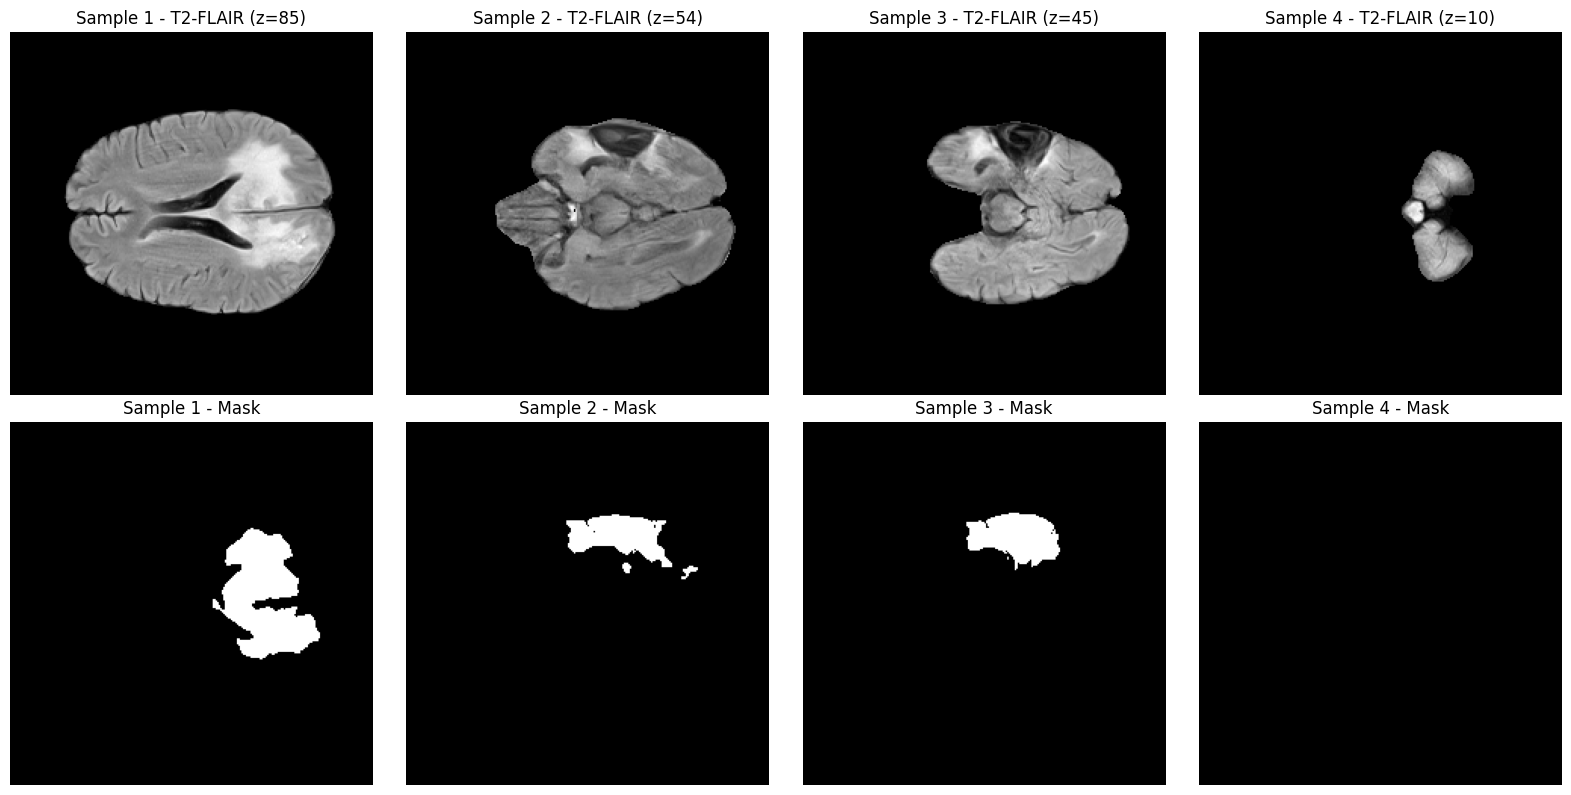


Volume shape (H, W, Z): (240, 240, 155)
Unique mask values (sample z): [0.]


In [3]:
# Visualize sample multimodal slices from PKG-MU source
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i in range(4):
    idx = np.random.randint(0, len(sample_records))
    rec = sample_records[idx]
    vols = load_timepoint_volumes(Path(rec['timepoint_dir']))
    z = rec['z']

    # Use FLAIR-equivalent channel (t2f) for top row quick preview
    img = minmax_norm_2d(vols['t2f'][:, :, z])
    mask = (vols['mask'][:, :, z] > 0).astype(np.float32)

    axes[0, i].imshow(img, cmap='gray')
    axes[0, i].set_title(f"Sample {i+1} - T2-FLAIR (z={z})")
    axes[0, i].axis('off')

    axes[1, i].imshow(mask, cmap='gray')
    axes[1, i].set_title(f"Sample {i+1} - Mask")
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Check data dimensions from one random record
rec0 = sample_records[0]
vols0 = load_timepoint_volumes(Path(rec0['timepoint_dir']))
print(f"\nVolume shape (H, W, Z): {vols0['t1n'].shape}")
print(f"Unique mask values (sample z): {np.unique((vols0['mask'][:, :, rec0['z']] > 0).astype(np.float32))}")

## 3. Custom Dataset Class

In [4]:
class BrainTumorDataset(Dataset):
    """Custom Dataset for PKG-MU NIfTI slices with 4-channel multimodal input."""

    def __init__(self, sample_records, transform=None, img_size=256, patch_transform=None):
        self.sample_records = sample_records
        self.transform = transform
        self.img_size = img_size
        self.patch_transform = patch_transform
        self._cache = {}

    def __len__(self):
        return len(self.sample_records)

    def _get_vols(self, timepoint_dir: str) -> dict:
        if timepoint_dir not in self._cache:
            self._cache[timepoint_dir] = load_timepoint_volumes(Path(timepoint_dir))
        return self._cache[timepoint_dir]

    def _build_image_mask(self, idx):
        rec = self.sample_records[idx]
        vols = self._get_vols(rec['timepoint_dir'])
        z = int(rec['z'])

        # 4-channel input as requested: t1n, t1c, t2w, t2f
        ch_t1n = minmax_norm_2d(vols['t1n'][:, :, z])
        ch_t1c = minmax_norm_2d(vols['t1c'][:, :, z])
        ch_t2w = minmax_norm_2d(vols['t2w'][:, :, z])
        ch_t2f = minmax_norm_2d(vols['t2f'][:, :, z])
        image = np.stack([ch_t1n, ch_t1c, ch_t2w, ch_t2f], axis=-1).astype(np.float32)  # [H,W,4]

        # Binary tumor mask
        mask = (vols['mask'][:, :, z] > 0).astype(np.float32)  # [H,W]

        return image, mask

    def get_raw_item(self, idx):
        """Get raw sample without transforms (for sampler analysis)."""
        image, mask = self._build_image_mask(idx)
        image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
        mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)

        image = torch.from_numpy(image).permute(2, 0, 1)  # [4,H,W]
        mask = torch.from_numpy(mask).unsqueeze(0)         # [1,H,W]
        return image, mask

    def __getitem__(self, idx):
        image, mask = self._build_image_mask(idx)

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask'].unsqueeze(0)
        else:
            image = cv2.resize(image, (self.img_size, self.img_size), interpolation=cv2.INTER_LINEAR)
            mask = cv2.resize(mask, (self.img_size, self.img_size), interpolation=cv2.INTER_NEAREST)
            image = torch.from_numpy(image).permute(2, 0, 1)
            mask = torch.from_numpy(mask).unsqueeze(0)

        # Patch-based training sampler (2D equivalent of volume patching)
        if self.patch_transform is not None:
            sample = {'image': image, 'label': mask}
            patch_samples = self.patch_transform(sample)
            if isinstance(patch_samples, list):
                patch = patch_samples[np.random.randint(0, len(patch_samples))]
            else:
                patch = patch_samples
            image = patch['image']
            mask = patch['label']

        return image, mask

## 5. Loss Functions and Metrics

In [5]:
class OptimalBrainTumorLoss(nn.Module):
    """Optimal hybrid loss for brain tumor segmentation using MONAI"""
    def __init__(self):
        super().__init__()
        # Primary: DiceCE for overall performance
        self.dice_ce = DiceCELoss(
            sigmoid=True,
            squared_pred=True,
            lambda_dice=0.6,
            lambda_ce=0.4
        )
        
        # Secondary: Focal for hard examples (boundaries)
        self.focal = FocalLoss(
            gamma=2.0,
            alpha=0.75  # Weight positive class
        )
    
    def forward(self, pred, target):
        # 70% DiceCE + 30% Focal
        dice_ce_loss = self.dice_ce(pred, target)
        focal_loss = self.focal(pred, target)
        
        total = 0.7 * dice_ce_loss + 0.3 * focal_loss
        
        return total


def dice_coefficient(pred, target, threshold=0.5):
    """Calculate Dice coefficient"""
    pred = torch.sigmoid(pred) > threshold
    pred = pred.float()
    
    intersection = (pred * target).sum()
    dice = (2. * intersection) / (pred.sum() + target.sum() + 1e-6)
    
    return dice.item()


def iou_score(pred, target, threshold=0.5):
    """Calculate Intersection over Union (IoU)"""
    pred = torch.sigmoid(pred) > threshold
    pred = pred.float()
    
    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection
    iou = intersection / (union + 1e-6)
    

    return iou.item()    


## 6. Data Preparation

In [6]:
# Split data into train/val/test at patient level (avoids patient leakage)
all_patients = sorted({r['patient_id'] for r in sample_records})

train_patients, temp_patients = train_test_split(
    all_patients, test_size=0.3, random_state=42
)
val_patients, test_patients = train_test_split(
    temp_patients, test_size=0.5, random_state=42
)

train_set = set(train_patients)
val_set = set(val_patients)
test_set = set(test_patients)

# Explicit leakage sanity checks
print(f"Patient overlap train∩val: {len(train_set.intersection(val_set))}")
print(f"Patient overlap train∩test: {len(train_set.intersection(test_set))}")
print(f"Patient overlap val∩test: {len(val_set.intersection(test_set))}")

train_records = [r for r in sample_records if r['patient_id'] in train_set]
val_records = [r for r in sample_records if r['patient_id'] in val_set]
test_records = [r for r in sample_records if r['patient_id'] in test_set]

print(f"Training samples: {len(train_records)}")
print(f"Validation samples: {len(val_records)}")
print(f"Test samples: {len(test_records)}")
print(f"Patients (train/val/test): {len(train_set)}/{len(val_set)}/{len(test_set)}")

# Create datasets
IMG_SIZE = 256
TRAIN_PATCH_SIZE = 128
BATCH_SIZE = 8

# Aggressive augmentation for medical images (training only)
train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),

    # Geometric augmentations
    A.Rotate(limit=20, p=0.7),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=20,
        p=0.7
    ),
    A.ElasticTransform(
        alpha=1,
        sigma=50,
        alpha_affine=50,
        p=0.3
    ),

    # Intensity augmentations
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussNoise(var_limit=(0.001, 0.005), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),

    # Normalization
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

# Validation/Test transform (only resize and normalize, no augmentation)
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=0.0, std=1.0),
    ToTensorV2()
])

# MONAI patch sampler (2D equivalent for this notebook's slice-based pipeline)
patch_transform = RandCropByPosNegLabeld(
    keys=["image", "label"],
    label_key="label",
    spatial_size=(TRAIN_PATCH_SIZE, TRAIN_PATCH_SIZE),
    pos=2, neg=1,
    num_samples=4
)

train_dataset = BrainTumorDataset(
    train_records,
    transform=train_transform,
    img_size=IMG_SIZE,
    patch_transform=patch_transform
)
val_dataset = BrainTumorDataset(val_records, transform=val_transform, img_size=IMG_SIZE)
test_dataset = BrainTumorDataset(test_records, transform=val_transform, img_size=IMG_SIZE)

# Create aggressive stratified sampler
def create_aggressive_sampler(dataset):
    """
    Aggressive stratified sampler specifically tuned for heavy empty-slice imbalance
    """
    weights = []
    stats = {
        'empty': 0,
        'very_small': 0,  # <50 pixels
        'small': 0,       # 50-500 pixels
        'medium': 0,      # 500-2000 pixels
        'large': 0        # >2000 pixels
    }

    print("\nAnalyzing dataset for aggressive stratified sampling...")
    for idx in range(len(dataset)):
        _, mask = dataset.get_raw_item(idx)
        tumor_pixels = mask.sum().item()

        # AGGRESSIVE weighting to reduce empty slices in training batches
        if tumor_pixels == 0:
            weight = 0.15
            stats['empty'] += 1
        elif tumor_pixels < 50:
            weight = 3.5
            stats['very_small'] += 1
        elif tumor_pixels < 500:
            weight = 2.8
            stats['small'] += 1
        elif tumor_pixels < 2000:
            weight = 1.5
            stats['medium'] += 1
        else:
            weight = 1.0
            stats['large'] += 1

        weights.append(weight)

    print("\n" + "="*60)
    print("STRATIFIED SAMPLING STATISTICS")
    print("="*60)
    print("Original distribution:")
    for k, v in stats.items():
        pct = 100 * v / len(dataset)
        print(f"  {k:12s}: {v:5d} ({pct:5.1f}%)")

    total_weight = sum(weights)
    print(f"\nEffective distribution after reweighting:")
    effective = {
        'empty': stats['empty'] * 0.15 / total_weight,
        'very_small': stats['very_small'] * 3.5 / total_weight,
        'small': stats['small'] * 2.8 / total_weight,
        'medium': stats['medium'] * 1.5 / total_weight,
        'large': stats['large'] * 1.0 / total_weight
    }
    for k, v in effective.items():
        print(f"  {k:12s}: {v*100:5.1f}%")
    print("="*60 + "\n")

    return WeightedRandomSampler(
        weights=torch.DoubleTensor(weights),
        num_samples=len(weights),
        replacement=True
    )

# Fast DataLoader settings for training
train_num_workers = 4
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=train_num_workers,
    pin_memory=torch.cuda.is_available(),
    persistent_workers=(train_num_workers > 0),
    prefetch_factor=4
)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

Patient overlap train∩val: 0
Patient overlap train∩test: 0
Patient overlap val∩test: 0
Training samples: 1705
Validation samples: 465
Test samples: 155
Patients (train/val/test): 4/1/1


## 7. Model Initialization

In [7]:
# Initialize model with attention mechanism
# Using segmentation_models_pytorch with all 4 MRI sequences
model = smp.UnetPlusPlus(
    encoder_name="efficientnet-b4", 
    encoder_weights="imagenet", 
    in_channels=4,                    # 4 MRI modalities: T1n, T1c, T2w, T2-FLAIR
    classes=1,                        # Binary segmentation
    activation=None,                  # Use logits for loss calculation
    decoder_attention_type='scse'     # Spatial and Channel Squeeze & Excitation
)

# Multi-GPU support (DataParallel)
if torch.cuda.is_available():
    if torch.cuda.device_count() > 1:
        print("Using", torch.cuda.device_count(), "GPUs")
        model = torch.nn.DataParallel(model)
    model = model.cuda()
else:
    model = model.to(device)

# Loss function and optimizer
# Optimal hybrid loss: 70% DiceCE + 30% Focal (MONAI implementation)
criterion = OptimalBrainTumorLoss()

# Use AdamW optimizer with weight decay for better regularization
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)

# Mixed precision scaler (enabled only on CUDA)
scaler = GradScaler(device='cuda', enabled=torch.cuda.is_available())
print(f"AMP enabled: {scaler.is_enabled()}")

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# ReduceLROnPlateau scheduler - monitors validation Dice score
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',          # Monitor DICE (higher is better)
    factor=0.5,          # Reduce LR by 50%
    patience=30,         # Wait 15 epochs before reducing
    min_lr=1e-7
)


AMP enabled: False
Total parameters: 20,924,860
Trainable parameters: 20,924,860


## 8. Training Loop

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device, scaler, epoch=0):
    """Train for one epoch with optional AMP."""
    model.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    amp_enabled = scaler.is_enabled()
    amp_device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
    
    for batch_idx, (images, masks) in enumerate(dataloader):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        # Forward pass (mixed precision on CUDA)
        with autocast(device_type=amp_device_type, enabled=amp_enabled):
            outputs = model(images)
            loss = criterion(outputs, masks)
        
        # Check for NaN/Inf before backward
        if torch.isnan(loss) or torch.isinf(loss):
            print(f"⚠️  NaN/Inf detected at epoch {epoch+1}, batch {batch_idx}")
            continue
        
        # Backward + optimizer step
        if amp_enabled:
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        
        # Calculate metrics
        dice = dice_coefficient(outputs, masks)
        iou = iou_score(outputs, masks)
        
        running_loss += loss.item()
        running_dice += dice
        running_iou += iou
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou


def validate_epoch(model, dataloader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device, non_blocking=True)
            masks = masks.to(device, non_blocking=True)
            
            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            # Calculate metrics
            dice = dice_coefficient(outputs, masks)
            iou = iou_score(outputs, masks)
            
            running_loss += loss.item()
            running_dice += dice
            running_iou += iou
    
    epoch_loss = running_loss / len(dataloader)
    epoch_dice = running_dice / len(dataloader)
    epoch_iou = running_iou / len(dataloader)
    
    return epoch_loss, epoch_dice, epoch_iou

In [ ]:
# Training configuration
NUM_EPOCHS = 200  # Train much longer for better convergence
EARLY_STOPPING_PATIENCE = 50  # More patience before stopping
CHECKPOINT_INTERVAL = 10  # Save checkpoint every N epochs
VALIDATE_EVERY = 3  # Run validation every 3 epochs
CHECKPOINT_PATH = 'checkpoint.pth'

# Remove old checkpoint to restart training from scratch
import os
if os.path.exists(CHECKPOINT_PATH):
    os.remove(CHECKPOINT_PATH)
    print(f"✓ Removed old checkpoint: {CHECKPOINT_PATH}")

# Training history
history = {
    'train_loss': [], 'train_dice': [], 'train_iou': [],
    'val_loss': [], 'val_dice': [], 'val_iou': []
}

best_val_dice = 0.0
early_stopping_counter = 0
start_epoch = 0

# Load checkpoint if exists
if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading checkpoint from {CHECKPOINT_PATH}...")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    history = checkpoint['history']
    best_val_dice = checkpoint['best_val_dice']
    early_stopping_counter = checkpoint['early_stopping_counter']
    print(f"✓ Resumed from epoch {start_epoch}")
    print(f"✓ Best validation Dice so far: {best_val_dice:.4f}\n")
else:
    print("No checkpoint found. Starting training from scratch...\n")

print("Starting training...\n")

for epoch in range(start_epoch, NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 50)
    
    # Train every epoch
    train_loss, train_dice, train_iou = train_epoch(
        model, train_loader, criterion, optimizer, device, scaler, epoch
    )
    
    # Save train history every epoch
    history['train_loss'].append(train_loss)
    history['train_dice'].append(train_dice)
    history['train_iou'].append(train_iou)
    
    # Validate every N epochs to reduce overhead
    do_validate = (epoch % VALIDATE_EVERY == 0)
    if do_validate:
        val_loss, val_dice, val_iou = validate_epoch(model, val_loader, criterion, device)
        scheduler.step(val_dice)
        
        history['val_loss'].append(val_loss)
        history['val_dice'].append(val_dice)
        history['val_iou'].append(val_iou)
        
        print(f"\nTrain Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Train IoU: {train_iou:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Dice: {val_dice:.4f} | Val IoU: {val_iou:.4f}")
        
        # Save best model only on validation epochs
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), 'best_unet_plusplus.pth')
            print(f"✓ Best model saved! (Dice: {best_val_dice:.4f})")
            early_stopping_counter = 0
        else:
            early_stopping_counter += 1
    else:
        print(f"\nTrain Loss: {train_loss:.4f} | Train Dice: {train_dice:.4f} | Train IoU: {train_iou:.4f}")
        print(f"Skipping validation this epoch (every {VALIDATE_EVERY} epochs)")
    
    # Save checkpoint periodically
    if (epoch + 1) % CHECKPOINT_INTERVAL == 0:
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_val_dice': best_val_dice,
            'early_stopping_counter': early_stopping_counter
        }
        torch.save(checkpoint, CHECKPOINT_PATH)
        print(f"💾 Checkpoint saved at epoch {epoch+1}")
    
    # Early stopping (evaluated only on validation epochs)
    if do_validate and early_stopping_counter >= EARLY_STOPPING_PATIENCE:

        print(f"\nEarly stopping triggered after {epoch+1} epochs")
        print("="*50)
        break

print(f"Training completed! Best Dice Score: {best_val_dice:.4f}")
print("="*50)

## 9. Training Visualization

In [ ]:
# Plot training history
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Dice Score
axes[1].plot(history['train_dice'], label='Train Dice')
axes[1].plot(history['val_dice'], label='Val Dice')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Dice Score')
axes[1].set_title('Training and Validation Dice Score')
axes[1].legend()
axes[1].grid(True)

# IoU Score
axes[2].plot(history['train_iou'], label='Train IoU')
axes[2].plot(history['val_iou'], label='Val IoU')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('IoU Score')
axes[2].set_title('Training and Validation IoU Score')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Test Set Evaluation

In [9]:
# Load best model
model.load_state_dict(torch.load('models/best_unet_plusplus.pth', map_location=device))

# Evaluate on test set
test_loss, test_dice, test_iou = validate_epoch(model, test_loader, criterion, device)

print("\n" + "="*50)
print("TEST SET RESULTS")
print("="*50)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Dice Score: {test_dice:.4f}")
print(f"Test IoU Score: {test_iou:.4f}")
print("="*50)

RuntimeError: Error(s) in loading state_dict for UnetPlusPlus:
	Missing key(s) in state_dict: "encoder._conv_stem.weight", "encoder._bn0.weight", "encoder._bn0.bias", "encoder._bn0.running_mean", "encoder._bn0.running_var", "encoder._blocks.0._depthwise_conv.weight", "encoder._blocks.0._bn1.weight", "encoder._blocks.0._bn1.bias", "encoder._blocks.0._bn1.running_mean", "encoder._blocks.0._bn1.running_var", "encoder._blocks.0._se_reduce.weight", "encoder._blocks.0._se_reduce.bias", "encoder._blocks.0._se_expand.weight", "encoder._blocks.0._se_expand.bias", "encoder._blocks.0._project_conv.weight", "encoder._blocks.0._bn2.weight", "encoder._blocks.0._bn2.bias", "encoder._blocks.0._bn2.running_mean", "encoder._blocks.0._bn2.running_var", "encoder._blocks.1._depthwise_conv.weight", "encoder._blocks.1._bn1.weight", "encoder._blocks.1._bn1.bias", "encoder._blocks.1._bn1.running_mean", "encoder._blocks.1._bn1.running_var", "encoder._blocks.1._se_reduce.weight", "encoder._blocks.1._se_reduce.bi

## 10.1. Test-Time Augmentation (TTA) + Post-Processing

Apply TTA and morphological post-processing to improve predictions

In [ ]:
import ttach as tta
from scipy import ndimage

# Load best model
model.load_state_dict(torch.load('models/best_unet_plusplus.pth', map_location=device))
model.eval()

print("="*60)
print("SETTING UP TTA + POST-PROCESSING")
print("="*60)

# === TTA Configuration ===
tta_transforms = tta.Compose([
    tta.HorizontalFlip(),
    tta.VerticalFlip(),
    tta.Rotate90(angles=[0, 90, 180, 270]),
    # Note: Scale removed - causes dimension issues with model stride requirements
])

tta_model = tta.SegmentationTTAWrapper(
    model, 
    tta_transforms, 
    merge_mode='mean'
)

print("✓ TTA model configured with transforms:")
print("  - Horizontal Flip")
print("  - Vertical Flip")
print("  - Rotation (0°, 90°, 180°, 270°)")
print(f"  - Total augmentations: {len(tta_transforms)}")
print("="*60 + "\n")

In [ ]:
# === POST-PROCESSING FUNCTION ===
def post_process(pred_prob, threshold=0.5):
    """
    Clean predictions using morphological operations
    
    Args:
        pred_prob: Probability map (H, W) with values [0, 1]
        threshold: Binary threshold (default: 0.5)
    
    Returns:
        Cleaned binary mask (H, W)
    """
    # Threshold to binary
    pred_binary = (pred_prob > threshold).astype(np.uint8)
    
    # Morphological opening (remove small noise)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    pred_binary = cv2.morphologyEx(pred_binary, cv2.MORPH_OPEN, kernel)
    
    # Morphological closing (fill small gaps)
    pred_binary = cv2.morphologyEx(pred_binary, cv2.MORPH_CLOSE, kernel)
    
    # Fill holes inside tumor regions
    pred_binary = ndimage.binary_fill_holes(pred_binary).astype(np.uint8)
    
    # Keep only largest connected component (main tumor)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(pred_binary, connectivity=8)
    if num_labels > 1:
        # Get largest component (ignore background label 0)
        largest_label = np.argmax(stats[1:, cv2.CC_STAT_AREA]) + 1
        pred_binary = (labels == largest_label).astype(np.uint8)
    
    return pred_binary

print("✓ Post-processing function defined")
print("  - Morphological opening (noise removal)")
print("  - Morphological closing (gap filling)")
print("  - Hole filling")
print("  - Largest component extraction")

In [ ]:
# === EVALUATE WITH TTA + POST-PROCESSING ===
def evaluate_tta_postprocess(tta_model, dataloader, device):
    """
    CORRECTED TTA evaluation: Threshold AFTER averaging predictions
    
    Args:
        tta_model: TTA-wrapped model
        dataloader: Test/validation dataloader
        device: Device to run on
    
    Returns:
        Average Dice score and IoU score
    """
    dice_scores = []
    iou_scores = []
    
    print("\nEvaluating with TTA + Post-processing...")
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Processing batches"):
            images = images.to(device)
            masks = masks.to(device)
            
            # TTA prediction: Multiple augmentations averaged FIRST
            preds_tta = tta_model(images)  # [B, 1, H, W] - averaged logits
            
            # Threshold AFTER TTA averaging (critical!)
            preds_prob = torch.sigmoid(preds_tta)
            
            # Apply post-processing to averaged predictions
            for i in range(preds_prob.shape[0]):
                pred_prob_2d = preds_prob[i, 0].cpu().numpy()  # (H, W)
                mask_2d = masks[i, 0].cpu().numpy()  # (H, W)
                
                # Post-process the averaged prediction
                pred_clean = post_process(pred_prob_2d, threshold=0.5)
                
                # Calculate metrics
                dice = dice_coefficient(
                    torch.from_numpy(pred_clean).unsqueeze(0).unsqueeze(0).float(),
                    torch.from_numpy(mask_2d).unsqueeze(0).unsqueeze(0).float()
                )
                
                iou = iou_score(
                    torch.from_numpy(pred_clean).unsqueeze(0).unsqueeze(0).float(),
                    torch.from_numpy(mask_2d).unsqueeze(0).unsqueeze(0).float()
                )
                
                dice_scores.append(dice)
                iou_scores.append(iou)
    
    return np.mean(dice_scores), np.mean(iou_scores)

print("✓ TTA + Post-processing evaluation function ready (CORRECTED)")
print("  - TTA averages predictions BEFORE thresholding")
print("  - Post-processing applied to averaged predictions")

## 10.2. Test Set Evaluation with TTA + Post-Processing

In [ ]:
# Evaluate on test set with TTA + Post-processing
print("\n" + "="*60)
print("TEST SET EVALUATION WITH TTA + POST-PROCESSING")
print("="*60)

tta_test_dice, tta_test_iou = evaluate_tta_postprocess(tta_model, test_loader, device)

print("\n" + "="*60)
print("COMPARISON: BASELINE vs TTA + POST-PROCESSING")
print("="*60)
print(f"\nBaseline Results:")
print(f"  Test Dice: {test_dice:.4f}")
print(f"  Test IoU:  {test_iou:.4f}")

print(f"\nTTA + Post-Processing Results:")
print(f"  Test Dice: {tta_test_dice:.4f} (Δ {tta_test_dice - test_dice:+.4f})")
print(f"  Test IoU:  {tta_test_iou:.4f} (Δ {tta_test_iou - test_iou:+.4f})")

if tta_test_dice > test_dice:
    improvement = ((tta_test_dice - test_dice) / test_dice) * 100
    print(f"\n✅ TTA + Post-processing improved Dice by {improvement:.2f}%")
else:
    print(f"\n⚠️  No improvement from TTA + Post-processing")

print("="*60)

## 11. Prediction Visualization

In [ ]:
def analyze_split_distribution(loader, name):
    """Analyze tumor size distribution in a dataset split"""
    tumor_sizes = []
    
    for images, masks in loader:
        # masks shape: [B, 1, H, W]
        masks_np = masks.numpy()
        for mask in masks_np:
            tumor_pixels = np.sum(mask)
            tumor_sizes.append(tumor_pixels)
    
    # Categorize by size
    empty = sum(1 for x in tumor_sizes if x == 0)
    tiny = sum(1 for x in tumor_sizes if 0 < x < 100)
    small = sum(1 for x in tumor_sizes if 100 <= x < 500)
    medium = sum(1 for x in tumor_sizes if 500 <= x < 2000)
    large = sum(1 for x in tumor_sizes if x >= 2000)
    
    total = len(tumor_sizes)
    
    print(f"\n{name} Distribution:")
    print(f"  Empty (0):        {empty:4d} ({100*empty/total:5.1f}%)")
    print(f"  Tiny (<100):      {tiny:4d} ({100*tiny/total:5.1f}%)")
    print(f"  Small (100-500):  {small:4d} ({100*small/total:5.1f}%)")
    print(f"  Medium (500-2k):  {medium:4d} ({100*medium/total:5.1f}%)")
    print(f"  Large (>2k):      {large:4d} ({100*large/total:5.1f}%)")
    print(f"  Total:            {total:4d}")

print("="*60)
print("DATASET SPLIT ANALYSIS")
print("="*60)
analyze_split_distribution(val_loader, "Validation")
analyze_split_distribution(test_loader, "Test")
print("="*60)

In [ ]:
def visualize_predictions(model, dataloader, device, num_samples=8):
    """Visualize model predictions"""
    model.eval()
    
    images_list = []
    masks_list = []
    preds_list = []
    
    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs) > 0.5
            
            images_list.append(images.cpu())
            masks_list.append(masks.cpu())
            preds_list.append(preds.cpu())
            
            if len(images_list) * images.size(0) >= num_samples:
                break
    
    images = torch.cat(images_list, dim=0)[:num_samples]
    masks = torch.cat(masks_list, dim=0)[:num_samples]
    preds = torch.cat(preds_list, dim=0)[:num_samples]
    
    # Plot
    fig, axes = plt.subplots(num_samples, 4, figsize=(16, num_samples * 4))
    
    for i in range(num_samples):
        # Original image (FLAIR channel)
        img = images[i, 1].numpy()  # FLAIR is channel 1
        axes[i, 0].imshow(img, cmap='gray')
        axes[i, 0].set_title('Input (FLAIR)')
        axes[i, 0].axis('off')
        
        # Ground truth
        mask = masks[i, 0].numpy()
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title('Ground Truth')
        axes[i, 1].axis('off')
        
        # Prediction
        pred = preds[i, 0].numpy()
        axes[i, 2].imshow(pred, cmap='gray')
        axes[i, 2].set_title('Prediction')
        axes[i, 2].axis('off')
        
        # Overlay
        overlay = np.stack([img, img, img], axis=-1)
        overlay[pred > 0] = [1, 0, 0]  # Red for prediction
        axes[i, 3].imshow(overlay)
        axes[i, 3].set_title('Overlay')
        axes[i, 3].axis('off')
    
    plt.tight_layout()
    plt.savefig('predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize predictions on test set
visualize_predictions(model, test_loader, device, num_samples=8)

## 13. Grad-CAM Explainability

Two complementary views of what the model has learned:

| Panel | What it shows |
|---|---|
| **Focus map** | A single heat-map overlay on the FLAIR image showing *where in the image* the model pays attention when making its segmentation decision. High-intensity regions (red) drove the model's output the most. |
| **Layer activation maps** | The same Grad-CAM computed at **four encoder depths** (shallow → bottleneck) and one **decoder** stage, revealing how feature abstraction progresses through the network. Early layers respond to low-level edges; deep layers respond to higher-level tumour context. |

### Implementation notes
* **No external library required** — hook-based Grad-CAM implemented from scratch.  
* **Scalar for backprop**: `sum(sigmoid(logits) × predicted_mask)` — this focuses the gradient signal on the predicted tumour region, producing sharper and more informative maps.
* **Target layers** are automatically discovered by scanning `model.encoder.named_modules()` for the last `Conv2d` in each encoder quarter, plus the final decoder block.


In [ ]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# ─────────────────────────────────────────────────────────────────────────────
#  Grad-CAM engine (hook-based, no external library)
# ─────────────────────────────────────────────────────────────────────────────

class SegGradCAM:
    """Gradient-weighted Class Activation Mapping for segmentation models.

    Registers one forward hook and one backward hook on ``target_layer``.
    Call ``__call__`` to compute the CAM for a single image.

    Parameters
    ----------
    model        : nn.Module  — the segmentation model (eval mode recommended)
    target_layer : nn.Module  — the layer to probe (must produce a 4-D feature map)
    """

    def __init__(self, model: nn.Module, target_layer: nn.Module):
        self.model = model
        self._acts: torch.Tensor | None = None
        self._grads: torch.Tensor | None = None

        self._fwd = target_layer.register_forward_hook(self._save_act)
        self._bwd = target_layer.register_full_backward_hook(self._save_grad)

    def _save_act(self, _m, _inp, out):
        self._acts = out.detach()

    def _save_grad(self, _m, _inp, grad_out):
        self._grads = grad_out[0].detach()

    def remove(self):
        """Remove hooks — call when done to free memory."""
        self._fwd.remove()
        self._bwd.remove()

    @torch.enable_grad()
    def __call__(
        self,
        image: torch.Tensor,             # (1, C, H, W)  on device
        roi_mask: torch.Tensor | None = None,  # (1, 1, H, W) optional focus region
    ) -> np.ndarray:
        """Return a [0,1]-normalised Grad-CAM heat-map (H×W numpy array)."""
        self.model.eval()
        self._acts = self._grads = None

        # ── Forward pass ─────────────────────────────────────────────────
        out = self.model(image)                        # (1, 1, H, W) logits
        prob = torch.sigmoid(out)

        # ── Scalar objective ─────────────────────────────────────────────
        # Back-prop signal: sum of predicted probability over the tumour
        # region predicted by the model (self-supervised → no GT needed).
        pred_mask = (prob > 0.5).float()
        if roi_mask is not None:
            roi = roi_mask.to(image.device)
            score = (prob * roi).sum()
        elif pred_mask.sum() > 0:
            score = (prob * pred_mask).sum()
        else:
            # No prediction — fall back to summing the whole map
            score = prob.sum()

        # ── Backward pass ────────────────────────────────────────────────
        self.model.zero_grad()
        score.backward()

        if self._grads is None or self._acts is None:
            return np.zeros(image.shape[-2:])

        # ── Grad-CAM formula ─────────────────────────────────────────────
        # α_k = (1/Z) Σ_{i,j} ∂score/∂A^k_{ij}   (global average pool)
        weights = self._grads.mean(dim=[2, 3], keepdim=True)  # (1, C, 1, 1)
        cam = (weights * self._acts).sum(dim=1)               # (1, H', W')
        cam = F.relu(cam).squeeze(0).cpu().numpy()            # (H', W')

        # ── Resize to input resolution ────────────────────────────────────
        H, W = image.shape[2], image.shape[3]
        if cam.shape == ():            # scalar edge case
            cam = np.full((H, W), float(cam))
        elif cam.ndim == 0:
            cam = np.full((H, W), float(cam))
        else:
            cam = cv2.resize(cam, (W, H), interpolation=cv2.INTER_LINEAR)

        # ── Normalise ─────────────────────────────────────────────────────
        cmin, cmax = cam.min(), cam.max()
        if cmax > cmin:
            cam = (cam - cmin) / (cmax - cmin)

        return cam


# ─────────────────────────────────────────────────────────────────────────────
#  Layer discovery — finds representative Conv2d layers at n encoder depths
# ─────────────────────────────────────────────────────────────────────────────

def discover_encoder_layers(model: nn.Module, n_depths: int = 4):
    """Return [(label, Conv2d), …] at ``n_depths`` evenly-spaced encoder depths.

    Works with any SMP encoder by scanning ``model.encoder.named_modules()``.
    Targets the last Conv2d in each n-th segment of the full module list,
    which reliably captures progressively deeper features without relying
    on hard-coded layer names.
    """
    convs = [
        (name, mod)
        for name, mod in model.encoder.named_modules()
        if isinstance(mod, nn.Conv2d)
    ]
    if not convs:
        raise RuntimeError("No Conv2d found in model.encoder — check SMP version.")

    n = len(convs)
    result = []
    for i in range(n_depths):
        idx  = min(int((i + 1) * n / n_depths) - 1, n - 1)
        name, mod = convs[idx]
        # Human-readable depth label
        parts = name.split(".")
        short = ".".join(parts[:min(4, len(parts))])
        label = f"Encoder depth {i + 1}  [{short}]"
        result.append((label, mod))
    return result


def get_decoder_layer(model: nn.Module):
    """Return (label, Conv2d) from the last/shallowest decoder block.

    SMP UNet++ stores decoder blocks in ``model.decoder.blocks``.
    The *last* block is closest to the full-resolution output and encodes
    the most semantically rich, spatially precise features.
    """
    for name, mod in reversed(list(model.decoder.named_modules())):
        if isinstance(mod, nn.Conv2d):
            parts = name.split(".")
            short = ".".join(parts[:min(4, len(parts))])
            return (f"Decoder shallowest  [{short}]", mod)
    raise RuntimeError("No Conv2d found in model.decoder")


# ─────────────────────────────────────────────────────────────────────────────
#  Visualisation helpers
# ─────────────────────────────────────────────────────────────────────────────

CMAP_HEAT = cm.get_cmap("jet")     # continuous heat-map
ALPHA_BLEND = 0.55                  # heatmap-over-image opacity


def _flair(image_t: torch.Tensor) -> np.ndarray:
    """Extract FLAIR (channel 1) as a 2-D [0,1] numpy array."""
    img = image_t[0, 1].cpu().numpy()
    mn, mx = img.min(), img.max()
    return (img - mn) / (mx - mn + 1e-8)


def _heatmap_overlay(flair_np: np.ndarray, cam: np.ndarray) -> np.ndarray:
    """Blend FLAIR greyscale image with a Jet colour-mapped CAM."""
    base   = np.stack([flair_np] * 3, axis=-1)               # (H,W,3)
    heat   = CMAP_HEAT(cam)[..., :3]                          # (H,W,3) RGBA→RGB
    blended = (1 - ALPHA_BLEND) * base + ALPHA_BLEND * heat
    return np.clip(blended, 0, 1)


def _add_colorbar(ax, vmin=0, vmax=1, label="GradCAM intensity"):
    """Append a colourbar to a matplotlib Axes."""
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
    sm   = cm.ScalarMappable(cmap=CMAP_HEAT, norm=norm)
    sm.set_array([])
    plt.colorbar(sm, ax=ax, fraction=0.046, pad=0.04, label=label)


# ─────────────────────────────────────────────────────────────────────────────
#  Panel 1 — Focus map  (single target layer, N test samples)
# ─────────────────────────────────────────────────────────────────────────────

def visualize_gradcam_focus(
    model,
    dataloader,
    device,
    num_samples: int = 6,
    prefer_tumour: bool = True,
):
    """5-column panel for each sample:
        FLAIR | GT mask | Prediction | Raw CAM heat-map | CAM overlay on FLAIR

    Target layer: last decoder Conv2d (highest spatial resolution, most
    semantically meaningful for tumour localisation).
    """
    # ── Discover target layer ─────────────────────────────────────────────
    target_label, target_layer = get_decoder_layer(model)
    gcam = SegGradCAM(model, target_layer)
    print(f"[Focus] Target layer: {target_label}")

    # ── Collect samples ───────────────────────────────────────────────────
    samples = []
    for imgs, masks in dataloader:
        for i in range(imgs.size(0)):
            if prefer_tumour and masks[i].sum() < 10:
                continue          # skip near-empty slices
            samples.append((imgs[i:i+1], masks[i:i+1]))
            if len(samples) >= num_samples:
                break
        if len(samples) >= num_samples:
            break

    if not samples:         # fall back if no tumour samples found
        for imgs, masks in dataloader:
            for i in range(imgs.size(0)):
                samples.append((imgs[i:i+1], masks[i:i+1]))
                if len(samples) >= num_samples:
                    break
            if len(samples) >= num_samples:
                break

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(
        len(samples), 5,
        figsize=(22, 4.4 * len(samples)),
        gridspec_kw={"wspace": 0.05, "hspace": 0.35},
    )
    if len(samples) == 1:
        axes = axes[np.newaxis, :]

    col_titles = ["FLAIR input", "Ground truth", "Prediction", "Grad-CAM heat-map", "CAM overlay"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=12, fontweight="bold", pad=8)

    for row, (img_t, mask_t) in enumerate(samples):
        img_dev = img_t.to(device)

        # Grad-CAM
        cam = gcam(img_dev)

        # Predictions
        with torch.no_grad():
            pred = (torch.sigmoid(model(img_dev)) > 0.5).float().cpu()

        flair = _flair(img_t)
        gt    = mask_t[0, 0].cpu().numpy()
        pr    = pred[0, 0].numpy()
        ovl   = _heatmap_overlay(flair, cam)

        axes[row, 0].imshow(flair, cmap="gray")
        axes[row, 1].imshow(gt,    cmap="gray")
        axes[row, 2].imshow(pr,    cmap="gray")
        axes[row, 3].imshow(cam,   cmap=CMAP_HEAT, vmin=0, vmax=1)
        axes[row, 4].imshow(ovl)

        # Dice for this sample
        intersection = (pr * gt).sum()
        dice_s = 2 * intersection / (pr.sum() + gt.sum() + 1e-8)
        axes[row, 4].set_xlabel(f"Dice = {dice_s:.3f}", fontsize=9)

        for ax in axes[row]:
            ax.axis("off")

    _add_colorbar(axes[-1, 3], label="Grad-CAM intensity")

    fig.suptitle(
        f"Grad-CAM Focus Maps  —  target: {target_label}",
        fontsize=14, fontweight="bold", y=1.01
    )
    plt.savefig("gradcam_focus.png", dpi=200, bbox_inches="tight")
    plt.show()
    gcam.remove()
    print("Saved: gradcam_focus.png")


# ─────────────────────────────────────────────────────────────────────────────
#  Panel 2 — Layer-by-layer activation maps across encoder depths
# ─────────────────────────────────────────────────────────────────────────────

def visualize_layer_gradcam(
    model,
    dataloader,
    device,
    n_encoder_depths: int = 4,
    num_samples: int = 4,
    prefer_tumour: bool = True,
):
    """Grid: rows = encoder depths + 1 decoder;  columns = test samples.

    Each cell shows the Grad-CAM heat-map computed with that specific layer
    as the target.  This reveals how feature abstraction progresses:
      * Depth 1  — low-level edges and intensity gradients
      * Depth 2  — tissue boundaries
      * Depth 3  — tumour shape context
      * Depth 4  — high-level semantic context (bottleneck)
      * Decoder  — final spatially-precise activation
    """
    # ── Discover target layers ────────────────────────────────────────────
    enc_layers = discover_encoder_layers(model, n_depths=n_encoder_depths)
    dec_label, dec_layer = get_decoder_layer(model)
    all_layers = enc_layers + [(dec_label, dec_layer)]
    n_layers   = len(all_layers)

    print("Target layers for layer-by-layer analysis:")
    for lbl, _ in all_layers:
        print(f"  • {lbl}")

    # ── Collect samples ───────────────────────────────────────────────────
    samples = []
    for imgs, masks in dataloader:
        for i in range(imgs.size(0)):
            if prefer_tumour and masks[i].sum() < 10:
                continue
            samples.append((imgs[i:i+1], masks[i:i+1]))
            if len(samples) >= num_samples:
                break
        if len(samples) >= num_samples:
            break

    if not samples:
        for imgs, masks in dataloader:
            for i in range(imgs.size(0)):
                samples.append((imgs[i:i+1], masks[i:i+1]))
                if len(samples) >= num_samples:
                    break
            if len(samples) >= num_samples:
                break

    # ── Plot ─────────────────────────────────────────────────────────────
    # rows = layers,  cols = samples
    FIG_W = max(5 * len(samples), 14)
    fig, axes = plt.subplots(
        n_layers, len(samples),
        figsize=(FIG_W, 3.8 * n_layers),
        gridspec_kw={"wspace": 0.05, "hspace": 0.45},
    )
    if n_layers == 1:
        axes = axes[np.newaxis, :]
    if len(samples) == 1:
        axes = axes[:, np.newaxis]

    for col, (img_t, _) in enumerate(samples):
        axes[0, col].set_title(f"Sample {col + 1}", fontsize=11, fontweight="bold", pad=6)

    for row, (lbl, layer) in enumerate(all_layers):
        gcam = SegGradCAM(model, layer)
        axes[row, 0].set_ylabel(
            lbl.split("[")[0].strip(),   # strip path for brevity
            fontsize=9, rotation=30, labelpad=70, va="center"
        )

        for col, (img_t, _) in enumerate(samples):
            img_dev = img_t.to(device)
            cam = gcam(img_dev)
            flair = _flair(img_t)
            ovl   = _heatmap_overlay(flair, cam)

            axes[row, col].imshow(ovl)
            axes[row, col].axis("off")

        gcam.remove()   # clean up hook before moving to next layer

    # Common colourbar
    _add_colorbar(
        axes[-1, -1],
        label="Grad-CAM  (0=inactive → 1=max activation)"
    )

    fig.suptitle(
        "Grad-CAM Layer-by-Layer Activation Maps\n"
        "(rows = encoder/decoder depth, columns = test samples)",
        fontsize=13, fontweight="bold", y=1.01
    )
    plt.savefig("gradcam_layers.png", dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved: gradcam_layers.png")


print("Grad-CAM engine loaded.")
print("  SegGradCAM         — hook-based Grad-CAM class")
print("  discover_encoder_layers() — auto-discovers encoder depth layers")
print("  visualize_gradcam_focus()   — focus heat-map panel")
print("  visualize_layer_gradcam()   — layer-by-layer activation panel")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  Run Grad-CAM explainability
# ─────────────────────────────────────────────────────────────────────────────

# Ensure the best model weights are loaded
model.load_state_dict(torch.load('models/best_unet_plusplus.pth', map_location=device))
model.to(device)
model.eval()
print("Best model weights loaded.\n")

# ── Panel 1 — Focus maps ─────────────────────────────────────────────────────
# Shows WHERE the model focuses its attention when predicting the tumour mask.
# 6 representative test samples, each displayed in 5 columns:
#   FLAIR | Ground truth | Prediction | Raw Grad-CAM | Grad-CAM overlay
print("=" * 60)
print("PANEL 1 — Grad-CAM Focus Maps")
print("  Target: last decoder Conv2d (highest-resolution, most semantic)")
print("=" * 60)

visualize_gradcam_focus(
    model         = model,
    dataloader    = test_loader,
    device        = device,
    num_samples   = 6,       # number of test samples to display
    prefer_tumour = True,    # prefer samples with visible tumour
)

print()

# ── Panel 2 — Layer-by-layer activation maps ─────────────────────────────────
# Shows HOW feature abstraction progresses through the encoder.
# Rows = 4 encoder depths + 1 decoder stage
# Columns = 4 test samples
# Reading the grid top-to-bottom reveals:
#   Depth 1 → low-level edge/intensity responses
#   Depth 2 → tissue boundary features
#   Depth 3 → tumour shape context
#   Depth 4 → high-level semantic features (bottleneck)
#   Decoder → final spatially-precise segmentation focus
print("=" * 60)
print("PANEL 2 — Layer-by-Layer Grad-CAM Activation Maps")
print("  Rows = encoder depths (1=shallow → 4=bottleneck) + decoder")
print("  Columns = test samples")
print("=" * 60)

visualize_layer_gradcam(
    model            = model,
    dataloader       = test_loader,
    device           = device,
    n_encoder_depths = 4,    # number of encoder depth layers to probe
    num_samples      = 4,    # test samples to show as columns
    prefer_tumour    = True,
)


## 14. Save Final Model


In [ ]:
# Save final model with metadata
torch.save({
    'epoch': len(history['train_loss']),
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'best_val_dice': best_val_dice,
    'test_dice': test_dice,
    'test_iou': test_iou,
    'history': history
}, 'unet_plusplus_final.pth')

print("Final model saved successfully!")

## 15. Model Summary


In [ ]:
print("\n" + "="*60)
print("UNet++ MODEL SUMMARY")
print("="*60)
print(f"Architecture: UNet++ with Nested Skip Connections")
print(f"Input Size: {IMG_SIZE}x{IMG_SIZE}x4 (4 MRI modalities)")
print(f"Output: Binary segmentation mask")
print(f"Total Parameters: {total_params:,}")
print(f"\nTraining Data: {len(train_records)} slices ({len(train_set)} patients)")
print(f"Validation Data: {len(val_records)} slices ({len(val_set)} patients)")
print(f"Test Data: {len(test_records)} slices ({len(test_set)} patients)")
print(f"\nBest Validation Dice: {best_val_dice:.4f}")
print(f"Test Dice Score: {test_dice:.4f}")
print(f"Test IoU Score: {test_iou:.4f}")
print("="*60)